In [86]:
import osmnx as ox

G = ox.graph_from_place("Düsseldorf, Germany", network_type="walk")

nodes, edges = ox.graph_to_gdfs(G)

print(nodes.columns)

nodes

Index(['y', 'x', 'street_count', 'highway', 'railway', 'ref', 'geometry'], dtype='str')


,y,x,street_count,highway,railway,ref,geometry
osmid,,,,,,,
164798,51.297523,6.768827,3,NaN,NaN,NaN,POINT (6.76883 51.29752)
164816,51.274093,6.748552,3,motorway_junction,NaN,NaN,POINT (6.74855 51.27409)
164831,51.284244,6.780934,3,NaN,NaN,NaN,POINT (6.78093 51.28424)
164832,51.284796,6.780199,3,NaN,NaN,NaN,POINT (6.7802 51.2848)
164836,51.283107,6.775194,3,NaN,NaN,NaN,POINT (6.77519 51.28311)
...,...,...,...,...,...,...,...
13603093699,51.262464,6.737364,3,NaN,NaN,NaN,POINT (6.73736 51.26246)
13603093700,51.262331,6.737092,3,NaN,NaN,NaN,POINT (6.73709 51.26233)
13603124401,51.262649,6.736911,4,NaN,NaN,NaN,POINT (6.73691 51.26265)


## Coords

In [87]:
rheinturm = (6.761774, 51.218032)
koelnerstraße_28 = (6.793714, 51.226780)

## nächsten Punkt im Graphen finden

### Euklidische Distanz

$d(p, q) = \sqrt{\sum_{i=1}^{n} (q_i - p_i)^2}$

oder einfacher

$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$

In [88]:
# find nearest points with euklidean distance

def find_nearest_nodes(nodes, coords):
    x, y = coords

    min_distance = float('inf')
    nearest_node_id = None

    for node_id, row in nodes.iterrows():
        node_x = row.geometry.x
        node_y = row.geometry.y
        
        distance = ((x - node_x) ** 2 + (y - node_y) ** 2) ** (1/2)
        
        if distance < min_distance:
            min_distance = distance
            nearest_node_id = node_id
    
    return nearest_node_id


trm_node  = find_nearest_nodes(nodes=nodes, coords=rheinturm)
klnstr_node = find_nearest_nodes(nodes=nodes, coords=koelnerstraße_28)

## Nodes geplotted

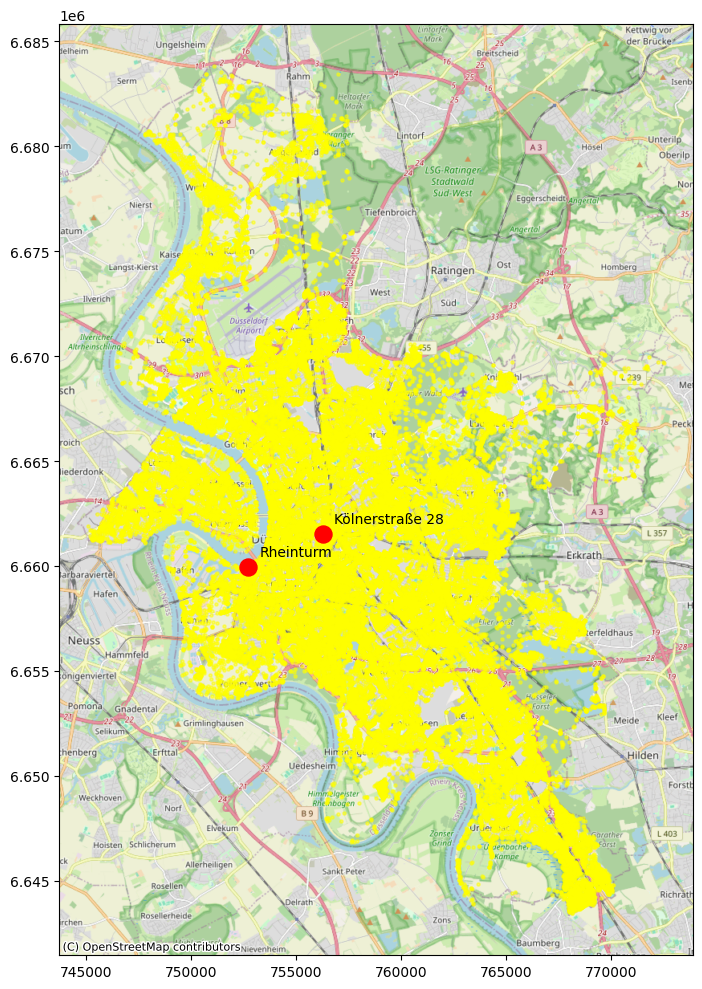

In [89]:
import matplotlib.pyplot as plt
import contextily as ctx

fig, ax = plt.subplots(figsize=(10, 10))

nodes_wm = nodes.to_crs(epsg=3857)
nodes_wm.plot(ax=ax, color='yellow', markersize=5, label='Nodes', alpha=0.5)

import geopandas as gpd
from shapely.geometry import Point

origin_points = {
    'Rheinturm': rheinturm,
    'Kölnerstraße 28': koelnerstraße_28
}

for name, (x, y) in origin_points.items():
    gdf = gpd.GeoDataFrame(geometry=[Point(x, y)], crs="EPSG:4326").to_crs(epsg=3857)
    px, py = gdf.geometry.x[0], gdf.geometry.y[0]
    ax.scatter(px, py, color='red', s=150, zorder=6)
    ax.annotate(name, (px, py), textcoords="offset points", xytext=(8, 8), fontsize=10)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.tight_layout()
plt.show()

## Haversine-Distanz

Für zwei Punkte auf einer Kugel mit den Koordinaten (φ₁, λ₁) und (φ₂, λ₂),  
wobei φ den Breitengrad und λ den Längengrad bezeichnet:

$$a = \sin^2\left(\frac{\Delta\varphi}{2}\right) + \cos(\varphi_1) \cdot \cos(\varphi_2) \cdot \sin^2\left(\frac{\Delta\lambda}{2}\right)$$

$$c = 2 \cdot \arcsin\left(\sqrt{a}\right)$$

$$d = r \cdot c$$

**Variablen:**
| Symbol | Bedeutung |
|--------|-----------|
| $d$ | gesuchte Entfernung |
| $r$ | Kugelradius (Erde ≈ 6371 km) |
| $\Delta\varphi$ | $\varphi_2 - \varphi_1$ (Differenz der Breitengrade) |
| $\Delta\lambda$ | $\lambda_2 - \lambda_1$ (Differenz der Längengrade) |

In [90]:
import numpy as np

def haversine(start, ende):
    earth_radius = 6371

    lat1, lat2 = np.radians(start[1]), np.radians(ende[1])
    lon1, lon2 = np.radians(start[0]), np.radians(ende[0])

    Δlat = lat2 - lat1
    Δlon = lon2 - lon1

    a = np.sin(Δlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(Δlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return c * earth_radius



print(f"Luftdistanz von {haversine(rheinturm, koelnerstraße_28):0.2f} km zwischen Rheinturm und Kölnerstraße.")

Luftdistanz von 2.43 km zwischen Rheinturm und Kölnerstraße.
